In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("loan_data.csv")
df.sample(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
5467,24.0,male,Master,55228.0,3,MORTGAGE,1500.0,MEDICAL,11.01,0.03,2.0,668,No,0
14378,22.0,male,Bachelor,127280.0,0,MORTGAGE,7500.0,EDUCATION,11.01,0.06,2.0,598,Yes,0
20096,28.0,male,Associate,25004.0,3,RENT,4000.0,HOMEIMPROVEMENT,13.11,0.16,6.0,516,No,1
8838,25.0,male,Bachelor,72804.0,3,MORTGAGE,4000.0,DEBTCONSOLIDATION,5.99,0.05,4.0,623,Yes,0
34840,25.0,female,Bachelor,87232.0,0,MORTGAGE,16965.0,MEDICAL,7.50,0.19,4.0,638,No,0


In [3]:
df.shape

(45000, 14)

In [4]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [5]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

In [6]:
education_mapping = {
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
}

df['person_education']=df['person_education'].map(education_mapping)

In [7]:
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,3,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,0,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,0,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,2,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,3,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [8]:
df['person_gender']=df['person_gender'].map({'male':0,'female':1})
df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].map({'No':0,"Yes":1})

In [9]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,1,3,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,0,1
1,21.0,1,0,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,1,0
2,25.0,1,0,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,0,1
3,23.0,1,2,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,0,1
4,24.0,0,3,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,0,1


In [10]:
df=pd.get_dummies(df,columns=['person_home_ownership','loan_intent'],drop_first=True,dtype=int)

In [11]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,0,0,1,0,0,0,1,0
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,0,1,0,1,0,0,0,0
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,0,0,0,0,0,1,0,0
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,0,0,1,0,0,1,0,0
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,0,1,47971.0,6,15000.0,15.66,0.31,3.0,645,0,1,0,0,1,0,0,1,0,0
44996,37.0,1,1,65800.0,17,9000.0,14.07,0.14,11.0,621,0,1,0,0,1,0,1,0,0,0
44997,33.0,0,1,56942.0,7,2771.0,10.02,0.05,10.0,668,0,1,0,0,1,0,0,0,0,0
44998,29.0,0,2,33164.0,4,12000.0,13.23,0.36,6.0,604,0,1,0,0,1,1,0,0,0,0


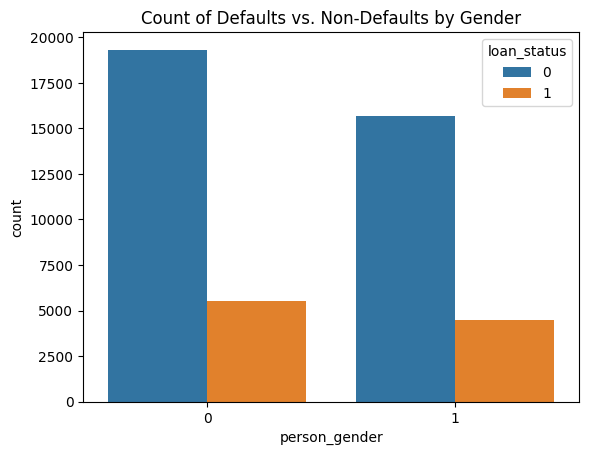

In [12]:
# This will show separate bars for Good Loans (0) and Defaults (1) side-by-side
sns.countplot(data=df, x='person_gender', hue='loan_status')
plt.title('Count of Defaults vs. Non-Defaults by Gender')
plt.show()


In [16]:
df.sample(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
41492,43.0,0,0,36768.0,16,3000.0,12.35,0.08,12.0,645,0,0,0,0,1,0,0,1,0,0
44318,25.0,1,1,75541.0,0,20000.0,10.53,0.26,3.0,696,0,1,0,0,1,0,0,1,0,0
21401,34.0,1,0,58981.0,13,7500.0,6.62,0.13,7.0,595,0,0,0,0,0,0,0,0,1,0


In [20]:
y=df['loan_status']
x=df.drop(columns=["loan_status"])

In [23]:
y=pd.DataFrame(y)

In [24]:
y

,loan_status
0,1
1,0
2,1
3,1
4,1
...,...
44995,1
44996,1
44997,1
44998,1


In [26]:
x

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,1,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,0,0,1,0,0,0,1,0
1,21.0,1,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,1,0,1,0,0,0,0
2,25.0,1,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,0,0,0,0,0,1,0,0
3,23.0,1,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,0,0,1,0,0,1,0,0
4,24.0,0,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,0,1,47971.0,6,15000.0,15.66,0.31,3.0,645,0,0,0,1,0,0,1,0,0
44996,37.0,1,1,65800.0,17,9000.0,14.07,0.14,11.0,621,0,0,0,1,0,1,0,0,0
44997,33.0,0,1,56942.0,7,2771.0,10.02,0.05,10.0,668,0,0,0,1,0,0,0,0,0
44998,29.0,0,2,33164.0,4,12000.0,13.23,0.36,6.0,604,0,0,0,1,1,0,0,0,0


In [27]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)



In [29]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)



In [31]:
x_train_scaled.shape

(36000, 19)

In [34]:
from sklearn.linear_model import LogisticRegression


lr=LogisticRegression()

lr.fit(x_train_scaled,y_train)

c:\Users\rayph\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
y_pred=lr.predict(x_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [37]:
print(f"accuarcy score : {accuracy_score(y_test,y_pred)}")
print(f"confusion_matrix : {confusion_matrix(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

accuarcy score : 0.8936666666666667
confusion_matrix : [[6550  440]
 [ 517 1493]]
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.84      9000
weighted avg       0.89      0.89      0.89      9000



In [38]:
from sklearn.metrics import f1_score
f1_score(y_test,y_pred)

0.7572914024854172

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
lr_new = LogisticRegression(class_weight='balanced',max_iter=1000,solver='lbfgs')
lr_new.fit(x_train_scaled,y_train)

c:\Users\rayph\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [45]:
# -------------------------------------------------
# 📊  Quick evaluation for the model **lr_new**
# -------------------------------------------------
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
)

# -------------------------------------------------
# 1️⃣  Make predictions (already have X_test_scaled, y_test)
# -------------------------------------------------
y_pred = lr_new.predict(x_test_scaled)               # <-- your trained model
y_proba = lr_new.predict_proba(x_test_scaled)[:, 1]  # needed only for ROC‑AUC (optional)

# -------------------------------------------------
# 2️⃣  Compute the main metrics
# -------------------------------------------------
metrics = {
    "Accuracy":               accuracy_score(y_test, y_pred),
    "Precision":              precision_score(y_test, y_pred, zero_division=0),
    "Recall":                 recall_score(y_test, y_pred, zero_division=0),
    "F1‑Score":               f1_score(y_test, y_pred, zero_division=0),
    "F2‑Score":               fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    "Confusion Matrix":       confusion_matrix(y_test, y_pred),
    "Classification Report":  classification_report(y_test, y_pred, zero_division=0),
}

# -------------------------------------------------
# 3️⃣  Pretty‑print everything
# -------------------------------------------------
pd.set_option("display.max_colwidth", None)   # show full text for the report
print("\n=== lr_new – Model Evaluation ===\n")
print(f"Accuracy           : {metrics['Accuracy']:.4f}")
print(f"Precision          : {metrics['Precision']:.4f}")
print(f"Recall             : {metrics['Recall']:.4f}")
print(f"F1‑Score           : {metrics['F1‑Score']:.4f}")
print(f"F2‑Score (β=2)     : {metrics['F2‑Score']:.4f}\n")

print("Confusion Matrix:\n")
print(metrics["Confusion Matrix"], "\n")

print("Classification Report:\n")
print(metrics["Classification Report"])



=== lr_new – Model Evaluation ===

Accuracy           : 0.8592
Precision          : 0.6267
Recall             : 0.9139
F1‑Score           : 0.7436
F2‑Score (β=2)     : 0.8372

Confusion Matrix:

[[5896 1094]
 [ 173 1837]] 

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.84      0.90      6990
           1       0.63      0.91      0.74      2010

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.89      0.86      0.87      9000



In [46]:
print("Training set class counts:")
print(y_train.value_counts())
print("\nTest set class counts:")
print(y_test.value_counts())


Training set class counts:
loan_status
0              28010
1               7990
Name: count, dtype: int64

Test set class counts:
loan_status
0              6990
1              2010
Name: count, dtype: int64
